In [1]:
from functions import *

from minerva.transforms.transform import *
from minerva.transforms.random_transform import *

from minerva.data.readers import TiffReader

from minerva.data.datasets import SimpleDataset

from minerva.data.data_modules import MinervaDataModule

from minerva.models.ssl.byol import BYOL
from minerva.models.nets.image.deeplabv3 import DeepLabV3Backbone

from minerva.pipelines.lightning_pipeline import SimpleLightningPipeline
from lightning.pytorch.loggers.csv_logs import CSVLogger
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning import Trainer
from pathlib import Path



/usr/local/lib/python3.10/dist-packages/_distutils_hack/__init__.py:53: UserWarning: Reliance on distutils from stdlib is deprecated. Users must rely on setuptools to provide the distutils module. Avoid importing distutils or import setuptools first, and avoid setting SETUPTOOLS_USE_DISTUTILS=stdlib. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Variables

## Paths

In [2]:
data_path = '/workspaces/shared_data/seismic/f3_segmentation/images'
annotation_path = '/workspaces/shared_data/seismic/f3_segmentation/annotations'
pretrain_logs_path =  '/workspaces/Seismic-Byol/dev-seismic-byol/logs/train'
pretrain_ckpt_path = '/workspaces/Seismic-Byol/dev-seismic-byol/ckpt/train'

## Hyperparameters

In [3]:
x = 224
input_size = (x, x)

dataset_name = 'seam_ai'

learning_rate = 0.2
batch_size = 8
num_epochs = 20

single_channel = True
accelerator = 'gpu'

model_name = f'teste'

## Transforms

In [4]:
random_flip = RandomFlip(possible_axis=1)
random_crop = RandomCrop(crop_size=input_size)
random_rotation = RandomRotation(degrees=25, prob=0.2)
transpose = Transpose([2, 0, 1])
cast_to_tensor = CastTo(dtype=np.float32)

byol_transform_pipeline = TransformPipeline(
    [   
        random_crop,
        random_flip,
        random_rotation,
        transpose,
        cast_to_tensor,
        ]
) 

constrastive_transform = ContrastiveTransform(
    byol_transform_pipeline
)

## Data Visualization

In [5]:
tiff_reader = TiffReader(path = data_path)
image_example = tiff_reader[0]

cropped_image = random_crop(image_example)
flipped_image = random_flip(cropped_image)
rotated_image = random_rotation(flipped_image)
final_image = byol_transform_pipeline(image_example)

In [6]:
image_example.shape, cropped_image.shape

((255, 701, 3), (224, 224, 3))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


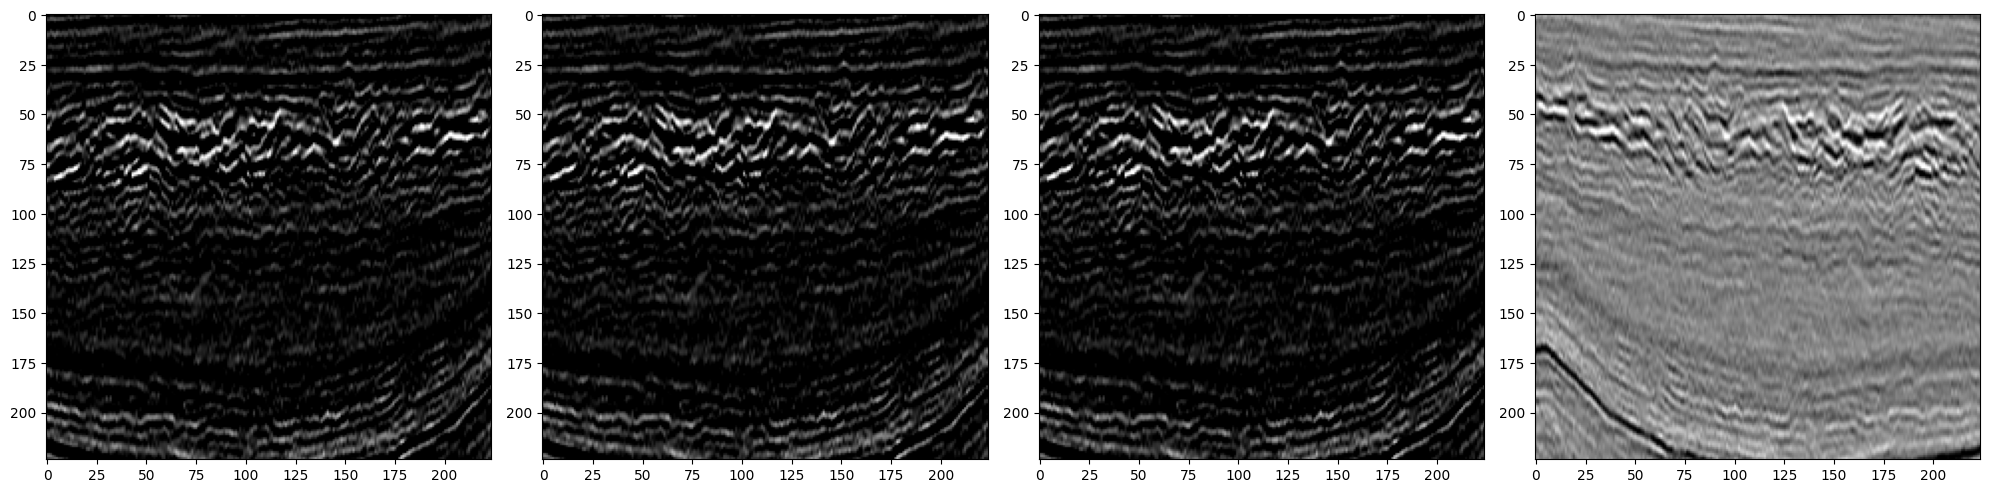

In [7]:
image_list = [
    cropped_image,
    flipped_image,
    rotated_image,
    final_image[0]
]
plot_images(image_list)

# Dataset

## Readers

In [8]:
train_img_reader_01 = TiffReader(path=data_path)
train_img_reader_02 = TiffReader(path=data_path)


pretrain_dataset = SimpleDataset(
    readers=train_img_reader_01,
    transforms=constrastive_transform,
    return_single=True
)

# DataModule

In [9]:
data_module = MinervaDataModule(
    train_dataset=pretrain_dataset,
    batch_size=batch_size,
    drop_last=True,
    shuffle_train=True,
    name=dataset_name
)

In [10]:
# Testing Data Module

# data_module.setup("fit")
# (train_batch_x, train_batch_y) = next(iter(data_module.train_dataloader()))
# train_batch_y = next(iter(data_module.train_dataloader()))
# train_batch_x.shape, train_batch_y.shape
# len(train_batch_y)

# Model

In [11]:
backbone = DeepLabV3Backbone(
    num_classes=6
)

model = BYOL(
    backbone=backbone,
    learning_rate=learning_rate,
)


# Pipeline

## Trainer

In [12]:
log_dir = Path(pretrain_logs_path) / model_name / dataset_name
ckpt_dir = Path(pretrain_ckpt_path) / model_name / dataset_name
logger = CSVLogger(log_dir, name=model_name, version=dataset_name)
ckpt_callback = ModelCheckpoint(save_top_k=1, save_last=True, dirpath=ckpt_dir)

trainer = Trainer(
    accelerator='gpu', 
    logger=logger,
    callbacks=ckpt_callback,
    max_epochs=num_epochs,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [13]:
pipeline = SimpleLightningPipeline(
    model=model,
    trainer=trainer,
    log_dir=log_dir,
    save_run_status=True,
)

In [14]:
# pipeline.run(data_module, task='fit')

In [15]:
from functions import *

In [16]:
model = get_model(
    "coco", 
    0.001,
    False,
    0,
    None
)
model.backbone

Using cache found in /home/vscode/.cache/torch/hub/pytorch_vision_v0.10.0
/home/vscode/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vscode/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


IntermediateLayerGetter(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1

In [17]:
model = get_model(
    "imagenet", 
    0.001,
    False,
    0,
    None
)
model

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
